<a href="https://colab.research.google.com/github/hriddhisrivastav09/Deep_Learning-Assignments/blob/main/Assignment_06/Deep_Learning_Assignment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

path = kagglehub.dataset_download("zunorain/tomato-dataset-v2")

print("Path to dataset files:", path)

100%|██████████| 460M/460M [00:04<00:00, 111MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1


In [2]:
import os

print(os.listdir(path))

['augmented_dataset']


In [3]:
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")
    if dirs:
        print("Folders:", dirs[:10])

/root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1 -> 0 files
Folders: ['augmented_dataset']
/root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1/augmented_dataset -> 0 files
Folders: ['Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Target_Spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot']
/root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1/augmented_dataset/Tomato_Leaf_Mold -> 2975 files
/root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1/augmented_dataset/Tomato__Tomato_YellowLeaf__Curl_Virus -> 3209 files
/root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1/augmented_dataset/Tomato_healthy -> 3072 files
/root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1/augmented_dataset/Tomato_Spider_mites_Two_spotted_spid

In [4]:
dataset_path = path + "/augmented_dataset"

print(dataset_path)
print(os.listdir(dataset_path))

/root/.cache/kagglehub/datasets/zunorain/tomato-dataset-v2/versions/1/augmented_dataset
['Tomato_Leaf_Mold', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato_healthy', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Target_Spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot']


In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


In [6]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [7]:
train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

Found 24492 images belonging to 10 classes.


In [8]:
validation_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 6117 images belonging to 10 classes.


In [9]:
print(train_data.class_indices)

{'Tomato_Bacterial_spot': 0, 'Tomato_Early_blight': 1, 'Tomato_Late_blight': 2, 'Tomato_Leaf_Mold': 3, 'Tomato_Septoria_leaf_spot': 4, 'Tomato_Spider_mites_Two_spotted_spider_mite': 5, 'Tomato__Target_Spot': 6, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 7, 'Tomato__Tomato_mosaic_virus': 8, 'Tomato_healthy': 9}


In [10]:
num_classes = len(train_data.class_indices)

print("Number of classes:", num_classes)

Number of classes: 10


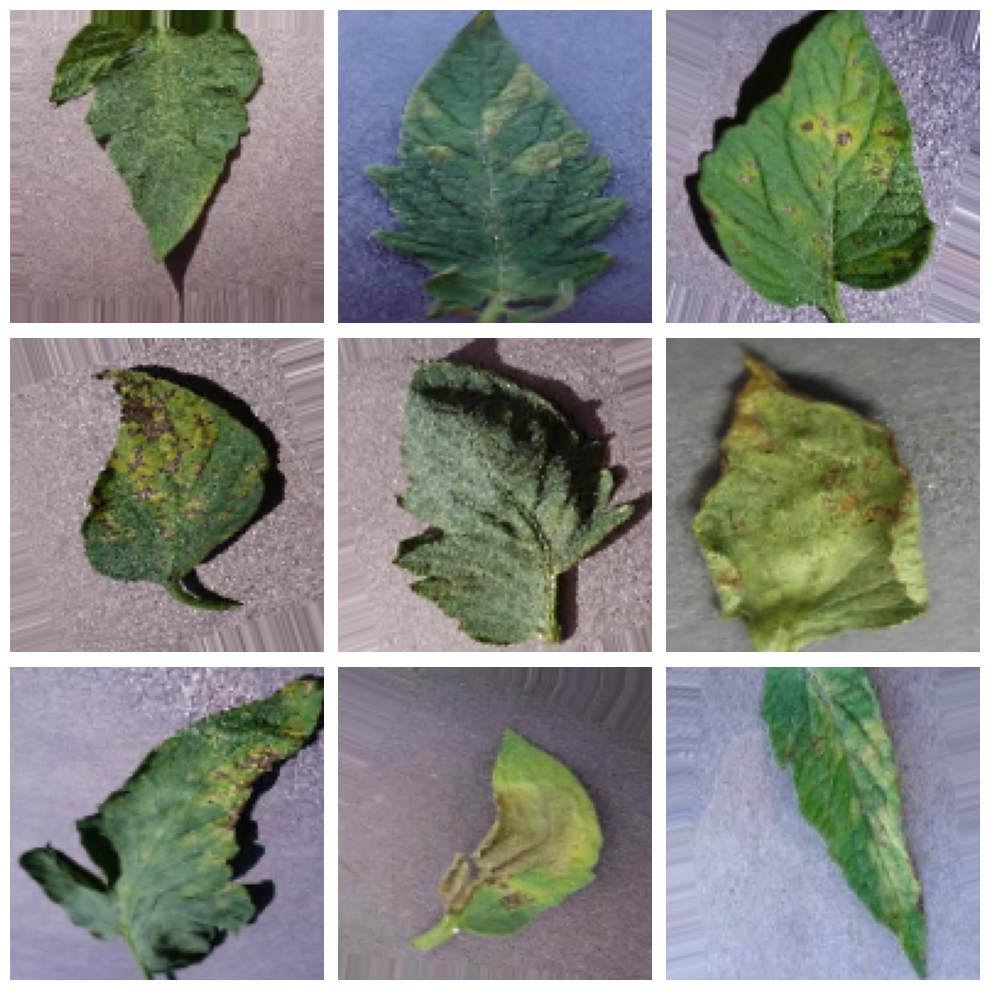

In [11]:
images, labels = next(train_data)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
model = Sequential([

    # Convolutional Layer 1
    Conv2D(32, (3, 3), activation='relu',
           input_shape=(128, 128, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Layer 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Convolutional Layer 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'),

    # Dropout
    Dropout(0.5),

    # Output Layer - 10 classes
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,930 (12.61 MB)

 Trainable params: 3,305,930 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 571s 743ms/step - accuracy: 0.4966 - loss: 1.4179 - val_accuracy: 0.6582 - val_loss: 0.9465
Epoch 2/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 563s 735ms/step - accuracy: 0.7046 - loss: 0.8414 - val_accuracy: 0.7888 - val_loss: 0.6141
Epoch 3/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 584s 762ms/step - accuracy: 0.7660 - loss: 0.6700 - val_accuracy: 0.8457 - val_loss: 0.4684
Epoch 4/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 588s 767ms/step - accuracy: 0.7946 - loss: 0.5900 - val_accuracy: 0.8628 - val_loss: 0.3955
Epoch 5/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 594s 731ms/step - accuracy: 0.8221 - loss: 0.5181 - val_accuracy: 0.8578 - val_loss: 0.4102
Epoch 6/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 579s 755ms/step - accuracy: 0.8351 - loss: 0.4663 - val_accuracy: 0.8501 - val_loss: 0.4116
Epoch 7/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 585s 763ms/step - accuracy: 0.8506 - loss: 0.4354 - val_accuracy: 0.8982 - val_loss: 0.2859
Epoch 8/10
766/766 ━━━━━━━━━━━━━━━━━━━━ 559s 730ms/step - accuracy: 0.8637 -

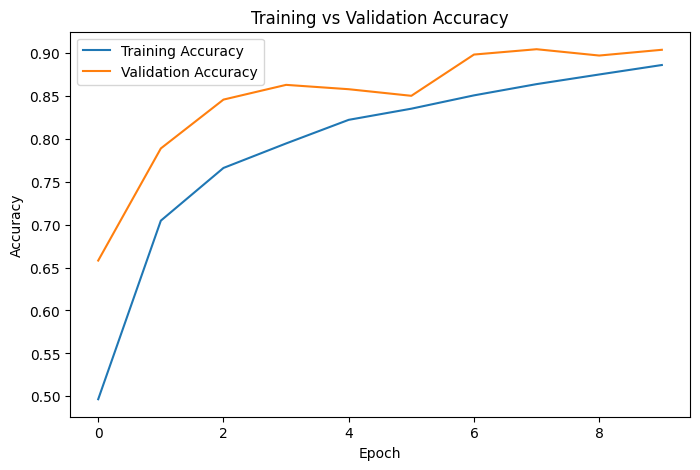

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

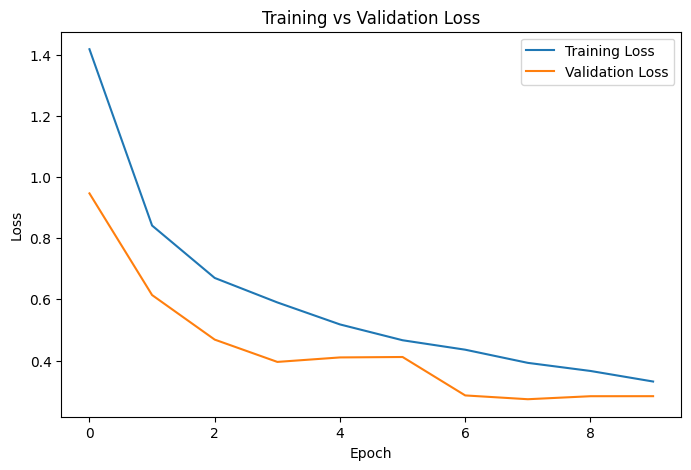

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [18]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

192/192 ━━━━━━━━━━━━━━━━━━━━ 45s 232ms/step - accuracy: 0.9008 - loss: 0.2865
Validation Loss: 0.28645381331443787
Validation Accuracy: 0.9007683396339417


In [19]:
model.save('/content/tomato_disease_cnn.h5')

In [20]:
from google.colab import files

files.download('/content/tomato_disease_cnn.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>